<a href="https://colab.research.google.com/github/ehdrb1023/GraduationProject/blob/main/Muon_SAM_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. 구글 드라이브 연동 (실행 후 링크나 팝업창에서 권한 허용 눌러줘!)
from google.colab import drive
import os
import urllib.request

drive.mount('/content/drive')

# 2. 구글 드라이브 내에 졸업프로젝트 전용 데이터 폴더 생성
drive_data_path = '/content/drive/MyDrive/Colab_Data'
os.makedirs(drive_data_path, exist_ok=True)

# 3. CIFAR-10 압축본 다운로드 URL 지정 (fast.ai의 초고속 미러 서버)
cifar_url = 'https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz'
destination_path = os.path.join(drive_data_path, 'cifar10.tgz')

# 4. 다운로드 시작
if not os.path.exists(destination_path):
    print("🚀 구글 드라이브로 CIFAR-10 압축 파일 다운로드를 시작합니다...")
    print("대략 10초~20초 정도 소요됩니다. 잠시만 기다려주세요.")

    urllib.request.urlretrieve(cifar_url, destination_path)

    print("\n✅ 다운로드 완료!")
    print(f"파일 저장 위치: {destination_path}")
    print(f"현재 파일 크기: {os.path.getsize(destination_path) / (1024*1024):.2f} MB")
else:
    print("✨ 이미 구글 드라이브에 cifar10.tgz 파일이 안전하게 존재합니다!")

Mounted at /content/drive
✨ 이미 구글 드라이브에 cifar10.tgz 파일이 안전하게 존재합니다!


In [2]:
import os
import time
import tarfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 현재 사용 중인 장치: {device}\n")

# ==========================================
# 1. 초고속 데이터 압축 해제 (Drive -> Colab Local)
# ==========================================
drive_zip_path = '/content/drive/MyDrive/Colab_Data/cifar10.tgz'
local_extract_path = '/content/'
local_data_path = '/content/cifar10'  # fast.ai 압축을 풀면 나오는 기본 폴더명

if not os.path.exists(local_data_path):
    print("📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)")
    with tarfile.open(drive_zip_path, 'r:gz') as tar:
        tar.extractall(path=local_extract_path)
    print("✅ 로컬 압축 해제 완료!\n")
else:
    print("✨ 이미 코랩 로컬에 데이터가 압축 해제되어 있습니다.\n")

# ==========================================
# 2. 데이터셋 및 데이터로더 설정 (Data Augmentation)
# ==========================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'train'), transform=transform_train)
test_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'test'), transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

print(f"📊 학습 데이터: {len(train_dataset)}장 | 테스트 데이터: {len(test_dataset)}장 준비 완료\n")

🖥️ 현재 사용 중인 장치: cuda

📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)


/tmp/ipykernel_1331/2377517764.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=local_extract_path)


✅ 로컬 압축 해제 완료!

📊 학습 데이터: 50000장 | 테스트 데이터: 10000장 준비 완료



In [3]:
# ==========================================
# 3. 모델 정의 (ResNet-18 for CIFAR-10)
# ==========================================
def build_model():
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 10)
    return m.to(device)

model = build_model()
print("✅ ResNet-18 모델 로드 및 CIFAR-10 커스텀 완료!\n")

✅ ResNet-18 모델 로드 및 CIFAR-10 커스텀 완료!



In [4]:
# ==========================================
# 4. Muon 옵티마이저 (v4: decoupled weight decay 추가)
# ==========================================
@torch.no_grad()
def zeropower_via_newtonschulz5(G, steps=5, eps=1e-7):
    """Newton-Schulz 반복을 통한 Gradient 직교화 (Muon의 핵심 연산)"""
    assert len(G.shape) == 2
    a, b, c = (3.4445, -4.7750,  2.0315)
    X = G.bfloat16()
    X /= (X.norm() + eps)
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X.to(G.dtype)

class Muon(optim.Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95, nesterov=True, ns_steps=5,
                 weight_decay=0.0):
        defaults = dict(lr=lr, momentum=momentum, nesterov=nesterov,
                        ns_steps=ns_steps, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                g = p.grad
                if g is None:
                    continue

                state = self.state[p]
                if 'momentum_buffer' not in state:
                    state['momentum_buffer'] = torch.zeros_like(g)
                buf = state['momentum_buffer']

                original_shape = g.shape
                if g.ndim > 2:
                    g = g.view(g.size(0), -1)

                g_ortho = zeropower_via_newtonschulz5(g, steps=group['ns_steps'])
                g_ortho = g_ortho.view(original_shape)

                buf.mul_(group['momentum']).add_(g_ortho)
                if group['nesterov']:
                    g_update = g_ortho + group['momentum'] * buf
                else:
                    g_update = buf

                # v4 추가: decoupled weight decay (AdamW 방식)
                if group['weight_decay'] > 0:
                    p.mul_(1 - group['lr'] * group['weight_decay'])

                p.add_(g_update, alpha=-group['lr'])
        return loss


def split_params(model, scope='hidden_only', verbose=True):
    """
    ★ v4의 핵심 수정.

    'all'         : v3와 동일 (ndim>=2 전부 Muon) — 재현/비교용
    'hidden_only' : Muon 공식 가이드 준수. 분류기 헤드(fc)와 stem conv(conv1)를
                    Muon에서 제외하고 AdamW로 보냄.
    """
    muon_p, adamw_p = [], []
    excluded = []
    for name, p in model.named_parameters():
        if p.ndim < 2:
            adamw_p.append(p)
            continue
        if scope == 'hidden_only' and (name.startswith('fc.') or name.startswith('conv1.')):
            adamw_p.append(p)
            excluded.append((name, tuple(p.shape), p.numel()))
            continue
        muon_p.append(p)

    if verbose:
        n_muon = sum(p.numel() for p in muon_p)
        n_adamw = sum(p.numel() for p in adamw_p)
        print(f"⚙️  MUON_SCOPE='{scope}'")
        print(f"    Muon : {len(muon_p):>3}개 텐서 / {n_muon:>11,} params")
        print(f"    AdamW: {len(adamw_p):>3}개 텐서 / {n_adamw:>11,} params")
        if excluded:
            print(f"    Muon에서 제외된 레이어:")
            for nm, sh, cnt in excluded:
                print(f"      - {nm:20s} {str(sh):18s} {cnt:>8,}")
        print()
    return muon_p, adamw_p

print("✅ Muon 옵티마이저(+weight decay) & 파라미터 분리 정책 정의 완료!\n")

✅ Muon 옵티마이저(+weight decay) & 파라미터 분리 정책 정의 완료!



In [5]:
# ==========================================
# 5. SAMAscent — 옵티마이저 독립적인 SAM perturbation (v3 그대로)
# ==========================================
class SAMAscent:
    """
    SAM을 '옵티마이저'가 아니라 '그래디언트 변환기'로 분리한 것.
    파라미터 perturbation만 담당하고 실제 step은 외부 옵티마이저(Muon/AdamW)에게 맡긴다.
    → 옵티마이저 객체를 바꾸지 않고도 SAM을 켤 수 있어 모멘텀/Adam 상태가 완벽히 연속된다.

    ascent()  : w -> w + rho * g/||g||
    restore() : w_adv -> w  (step은 호출자가 수행)
    """
    def __init__(self, params, rho=0.05):
        self.params = [p for p in params if p.requires_grad]
        self.rho = rho
        self._e_w = {}

    def set_rho(self, rho):
        self.rho = rho

    @torch.no_grad()
    def _grad_norm(self):
        grads = [p.grad.norm(p=2) for p in self.params if p.grad is not None]
        if not grads:
            return torch.tensor(0.0)
        return torch.norm(torch.stack(grads), p=2)

    @torch.no_grad()
    def ascent(self):
        if self.rho <= 0:
            return False
        grad_norm = self._grad_norm()
        if grad_norm.item() < 1e-12:
            return False
        scale = self.rho / (grad_norm + 1e-12)
        self._e_w.clear()
        for p in self.params:
            if p.grad is None:
                continue
            e_w = p.grad * scale.to(p.device)
            p.add_(e_w)
            self._e_w[p] = e_w
        return True

    @torch.no_grad()
    def restore(self):
        for p, e_w in self._e_w.items():
            p.sub_(e_w)
        self._e_w.clear()

print("✅ SAMAscent 정의 완료!\n")

✅ SAMAscent 정의 완료!



In [6]:
# ==========================================
# 6. 램프형 전환 컨트롤러 + 진단 함수 (v3 그대로)
# ==========================================
import collections

class RampSwitchController:
    """
    Phase 1 (rho=0)       : 순수 Muon+AdamW. Loss EMA + std 조건 만족 시 트리거
    Phase 2 (rho 램프 중) : rho가 0 -> rho_max로 ramp_epochs에 걸쳐 선형 증가
    Phase 3 (rho=rho_max) : 완전한 SAM-Muon

    Phase가 바뀌어도 옵티마이저는 교체되지 않는다. rho 값만 변한다.
    """
    def __init__(self, rho_max=0.05, ramp_epochs=5,
                 coarse_loss_threshold=0.5, coarse_window=3, coarse_std_threshold=0.03,
                 ema_alpha=0.3, mode='hybrid'):
        self.mode = mode
        self.rho_max = rho_max
        self.ramp_epochs = ramp_epochs
        self.coarse_loss_threshold = coarse_loss_threshold
        self.coarse_std_threshold = coarse_std_threshold
        self.ema_alpha = ema_alpha

        self.loss_ema = None
        self.loss_window = collections.deque(maxlen=coarse_window)
        self.trigger_epoch = None
        self.phase = 1

        if mode == 'sam_always':
            self.trigger_epoch = 0
            self.phase = 2

    def current_rho(self, epoch):
        if self.mode == 'muon_only':
            return 0.0
        if self.trigger_epoch is None:
            return 0.0
        progress = (epoch - self.trigger_epoch + 1) / max(1, self.ramp_epochs)
        progress = min(1.0, max(0.0, progress))
        return self.rho_max * progress

    def update(self, epoch, epoch_train_loss):
        if self.mode == 'muon_only':
            self.phase = 1
            return self.phase

        self.loss_ema = epoch_train_loss if self.loss_ema is None \
            else self.ema_alpha * epoch_train_loss + (1 - self.ema_alpha) * self.loss_ema
        self.loss_window.append(epoch_train_loss)

        if self.trigger_epoch is None and len(self.loss_window) == self.loss_window.maxlen:
            loss_std = torch.tensor(list(self.loss_window)).std().item()
            if self.loss_ema <= self.coarse_loss_threshold and loss_std <= self.coarse_std_threshold:
                self.trigger_epoch = epoch + 1
                self.phase = 2
                print(f"\n🔍 [Phase 1→2] Loss EMA={self.loss_ema:.4f}, std={loss_std:.4f} "
                      f"→ epoch {self.trigger_epoch}부터 rho 램프 시작 "
                      f"(0 → {self.rho_max} over {self.ramp_epochs} epochs)\n")

        if self.trigger_epoch is not None:
            if epoch + 1 >= self.trigger_epoch + self.ramp_epochs:
                if self.phase != 3:
                    print(f"\n🎯 [Phase 2→3] rho 램프 완료 → rho={self.rho_max} 고정, 완전 SAM-Muon\n")
                self.phase = 3
            else:
                self.phase = 2
        return self.phase


def measure_sharpness(model, criterion, probe_batches, device, rho=0.05):
    """고정 probe 배치로 sharpness L(w+eps)-L(w) 측정 (rho는 항상 0.05 고정 → 비교 가능)"""
    was_training = model.training
    model.eval()
    diffs = []
    for inputs, targets in probe_batches:
        inputs, targets = inputs.to(device), targets.to(device)

        with torch.no_grad():
            loss_w = criterion(model(inputs), targets).item()

        model.zero_grad(set_to_none=True)
        criterion(model(inputs), targets).backward()

        grads = [p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]
        grad_norm = torch.norm(torch.stack(grads), p=2)
        scale = rho / (grad_norm + 1e-12)

        e_ws = []
        with torch.no_grad():
            for p in model.parameters():
                if p.grad is None:
                    continue
                e_w = p.grad * scale
                p.add_(e_w)
                e_ws.append((p, e_w))
            loss_w_eps = criterion(model(inputs), targets).item()
            for p, e_w in e_ws:
                p.sub_(e_w)

        model.zero_grad(set_to_none=True)
        diffs.append(loss_w_eps - loss_w)

    if was_training:
        model.train()
    return sum(diffs) / len(diffs)


def evaluate(model_to_eval, loader):
    model_to_eval.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model_to_eval(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total

print("✅ 컨트롤러 + 진단 함수 정의 완료!\n")

✅ 컨트롤러 + 진단 함수 정의 완료!



In [7]:
# ==========================================
# 6.5. 고정 probe 배치  ★ 학습 셀들보다 먼저, 딱 한 번만 실행
# ==========================================
# v3의 문제: probe를 train_loader에서 매번 새로 뽑아서(shuffle+augmentation)
#            MODE마다 다른 이미지로 sharpness를 쟀음 → 값 비교가 불가능했음
# v4 수정  : 고정 seed로 뽑은 동일한 subset을 지금 텐서로 굳혀둠
from torch.utils.data import Subset, DataLoader

_g = torch.Generator().manual_seed(1234)
_probe_idx = torch.randperm(len(train_dataset), generator=_g)[:384].tolist()
_probe_loader = DataLoader(Subset(train_dataset, _probe_idx), batch_size=128, shuffle=False)

probe_batches = [(x.clone(), y.clone()) for x, y in _probe_loader]

print(f"✅ 고정 probe 배치 {len(probe_batches)}개 확보 "
      f"({sum(len(y) for _, y in probe_batches)}장)")
print("   → 모든 MODE가 동일 데이터로 sharpness 측정 (값 직접 비교 가능)\n")

✅ 고정 probe 배치 3개 확보 (384장)
   → 모든 MODE가 동일 데이터로 sharpness 측정 (값 직접 비교 가능)



In [8]:
# ==========================================
# 7. 학습 루프 (v4)
# ==========================================
# ┌────────────────────────────────────────────────────────────────┐
# │ 1단계 진단: QUICK_TEST=True, MODE='muon_only',                  │
# │             MUON_SCOPE='hidden_only' 로 15에폭 (~15분)          │
# │   → v3의 muon_only 15에폭 train acc = 85.19%                    │
# │     이보다 확실히 높으면 가설 적중                              │
# │                                                                 │
# │ 2단계 본실험: QUICK_TEST=False 로 muon_only → hybrid            │
# └────────────────────────────────────────────────────────────────┘
MODE = 'muon_only'          # 'muon_only' | 'sam_always' | 'hybrid'
MUON_SCOPE = 'hidden_only'  # ★ 'hidden_only'(권장) | 'all'(v3 재현)
QUICK_TEST = True           # True면 15에폭만

EPOCHS = 15 if QUICK_TEST else 50
MUON_LR = 0.02
MUON_WD = 0.0             # Muon weight decay (0.01~0.05 시도해볼 것)
ADAMW_LR = 3e-4
RHO_MAX = 0.05
RAMP_EPOCHS = 5
SHARPNESS_INTERVAL = 2
GRAD_CLIP = 1.0

torch.manual_seed(42)
model = build_model()

# ★ v4 핵심: scope 정책에 따라 파라미터 분리
muon_params, adamw_params = split_params(model, scope=MUON_SCOPE)

optimizer_muon = Muon(muon_params, lr=MUON_LR, momentum=0.95, weight_decay=MUON_WD)
optimizer_adamw = optim.AdamW(adamw_params, lr=ADAMW_LR, weight_decay=0.01)

sched_muon = optim.lr_scheduler.CosineAnnealingLR(optimizer_muon, T_max=EPOCHS)
sched_adamw = optim.lr_scheduler.CosineAnnealingLR(optimizer_adamw, T_max=EPOCHS)

sam = SAMAscent(model.parameters(), rho=0.0)

controller = RampSwitchController(
    rho_max=RHO_MAX, ramp_epochs=RAMP_EPOCHS,
    coarse_loss_threshold=0.5, coarse_window=3, coarse_std_threshold=0.03,
    mode=MODE,
)

criterion = nn.CrossEntropyLoss()

history = {'epoch': [], 'phase': [], 'rho': [], 'train_loss': [], 'train_acc': [],
           'test_acc': [], 'lr_muon': [], 'lr_adamw': [], 'grad_norm': [],
           'ascent_gap': [], 'time': []}
sharpness_history = {'epoch': [], 'sharpness': []}

RUN_TAG = f"{MODE}_{MUON_SCOPE}" + ("_quick" if QUICK_TEST else "")
print(f"🚀 CIFAR-10 학습 시작 — {RUN_TAG}, {EPOCHS} epochs\n")

for epoch in range(EPOCHS):
    rho_now = controller.current_rho(epoch)
    sam.set_rho(rho_now)
    phase = controller.phase

    model.train()
    running_loss, running_gap, running_gnorm = 0.0, 0.0, 0.0
    correct, total = 0, 0
    n_batches = 0
    start_time = time.time()

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer_muon.zero_grad(set_to_none=True)
        optimizer_adamw.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()

        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        with torch.no_grad():
            gnorm = torch.norm(torch.stack([
                p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]), p=2).item()
        running_gnorm += gnorm

        gap = 0.0
        if sam.ascent():
            optimizer_muon.zero_grad(set_to_none=True)
            optimizer_adamw.zero_grad(set_to_none=True)
            loss_adv = criterion(model(inputs), targets)
            loss_adv.backward()
            gap = loss_adv.item() - loss.item()
            sam.restore()

        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer_muon.step()
        optimizer_adamw.step()

        running_loss += loss.item()
        running_gap += gap
        n_batches += 1

    sched_muon.step()
    sched_adamw.step()

    epoch_time = time.time() - start_time
    train_loss = running_loss / n_batches
    train_acc = 100. * correct / total
    test_acc = evaluate(model, test_loader)

    history['epoch'].append(epoch + 1)
    history['phase'].append(phase)
    history['rho'].append(rho_now)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    history['lr_muon'].append(optimizer_muon.param_groups[0]['lr'])
    history['lr_adamw'].append(optimizer_adamw.param_groups[0]['lr'])
    history['grad_norm'].append(running_gnorm / n_batches)
    history['ascent_gap'].append(running_gap / n_batches)
    history['time'].append(epoch_time)

    sharp_str = ""
    if (epoch + 1) % SHARPNESS_INTERVAL == 0 or epoch == EPOCHS - 1:
        sv = measure_sharpness(model, criterion, probe_batches, device, rho=0.05)
        sharpness_history['epoch'].append(epoch + 1)
        sharpness_history['sharpness'].append(sv)
        sharp_str = f" | Sharp: {sv:.4f}"

    phase_tag = {1: "P1-Muon", 2: "P2-Ramp", 3: "P3-SAMMuon"}[phase]
    print(f"[{phase_tag}] Ep [{epoch+1}/{EPOCHS}] | {epoch_time:.1f}s | "
          f"Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}% | "
          f"rho: {rho_now:.4f}{sharp_str}")

    controller.update(epoch, train_loss)

best_acc = max(history['test_acc'])
best_epoch = history['epoch'][history['test_acc'].index(best_acc)]
final_sharpness = sharpness_history['sharpness'][-1]

print(f"\n🎉 학습 종료! ({RUN_TAG})")
print(f"   - 최종 Train Acc: {history['train_acc'][-1]:.2f}%")
print(f"   - 최종 Test Acc : {history['test_acc'][-1]:.2f}%")
print(f"   - 최고 Test Acc : {best_acc:.2f}% (epoch {best_epoch})")
print(f"   - 최종 Sharpness: {final_sharpness:.4f}")
print(f"   - 총 학습 시간  : {sum(history['time'])/60:.1f}분")

# ---- v3 대비 진단 ----
V3_REF = {15: {'train': 85.19, 'test': 82.11}, 50: {'train': 93.29, 'test': 86.20}}
if EPOCHS in V3_REF and MODE == 'muon_only':
    ref = V3_REF[EPOCHS]
    d_train = history['train_acc'][-1] - ref['train']
    d_test = history['test_acc'][-1] - ref['test']
    print(f"\n📌 v3 muon_only({EPOCHS}ep) 대비: "
          f"Train {ref['train']:.2f}% → {history['train_acc'][-1]:.2f}% ({d_train:+.2f}%p) | "
          f"Test {ref['test']:.2f}% → {history['test_acc'][-1]:.2f}% ({d_test:+.2f}%p)")
    if d_train > 1.5:
        print("   ✅ 가설 적중 — 분류기 헤드 직교화가 병목이었음이 확인됨. 본 실험 진행!")
    elif d_train > 0.3:
        print("   🤔 소폭 개선 — 방향은 맞지만 다른 병목도 있음. MUON_WD/MUON_LR도 함께 조정 권장")
    else:
        print("   ❌ 개선 없음 — scope는 원인이 아님. 아래 마크다운의 '가설이 틀렸을 때' 참고")

⚙️  MUON_SCOPE='hidden_only'
    Muon :  19개 텐서 /  11,157,504 params
    AdamW:  43개 텐서 /      24,138 params
    Muon에서 제외된 레이어:
      - conv1.weight         (64, 3, 7, 7)         9,408
      - fc.weight            (10, 512)             5,120

🚀 CIFAR-10 학습 시작 — muon_only_hidden_only_quick, 15 epochs

[P1-Muon] Ep [1/15] | 51.8s | Loss: 1.3960 | Train: 50.21% | Test: 62.55% | rho: 0.0000
[P1-Muon] Ep [2/15] | 48.7s | Loss: 1.0011 | Train: 65.32% | Test: 68.65% | rho: 0.0000 | Sharp: 1.0237
[P1-Muon] Ep [3/15] | 50.7s | Loss: 0.8567 | Train: 70.29% | Test: 73.10% | rho: 0.0000
[P1-Muon] Ep [4/15] | 52.2s | Loss: 0.7720 | Train: 73.76% | Test: 76.40% | rho: 0.0000 | Sharp: 0.6831
[P1-Muon] Ep [5/15] | 51.1s | Loss: 0.7028 | Train: 76.36% | Test: 76.14% | rho: 0.0000
[P1-Muon] Ep [6/15] | 50.7s | Loss: 0.6497 | Train: 78.03% | Test: 78.10% | rho: 0.0000 | Sharp: 0.7898
[P1-Muon] Ep [7/15] | 51.2s | Loss: 0.6041 | Train: 79.74% | Test: 79.72% | rho: 0.0000
[P1-Muon] Ep [8/15] | 51.7s | Los

/tmp/ipykernel_1331/4278299196.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8); ax.grid(alpha=0.3)
/tmp/ipykernel_1331/4278299196.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8); ax.grid(alpha=0.3)
/tmp/ipykernel_1331/4278299196.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8); ax.grid(alpha=0.3)


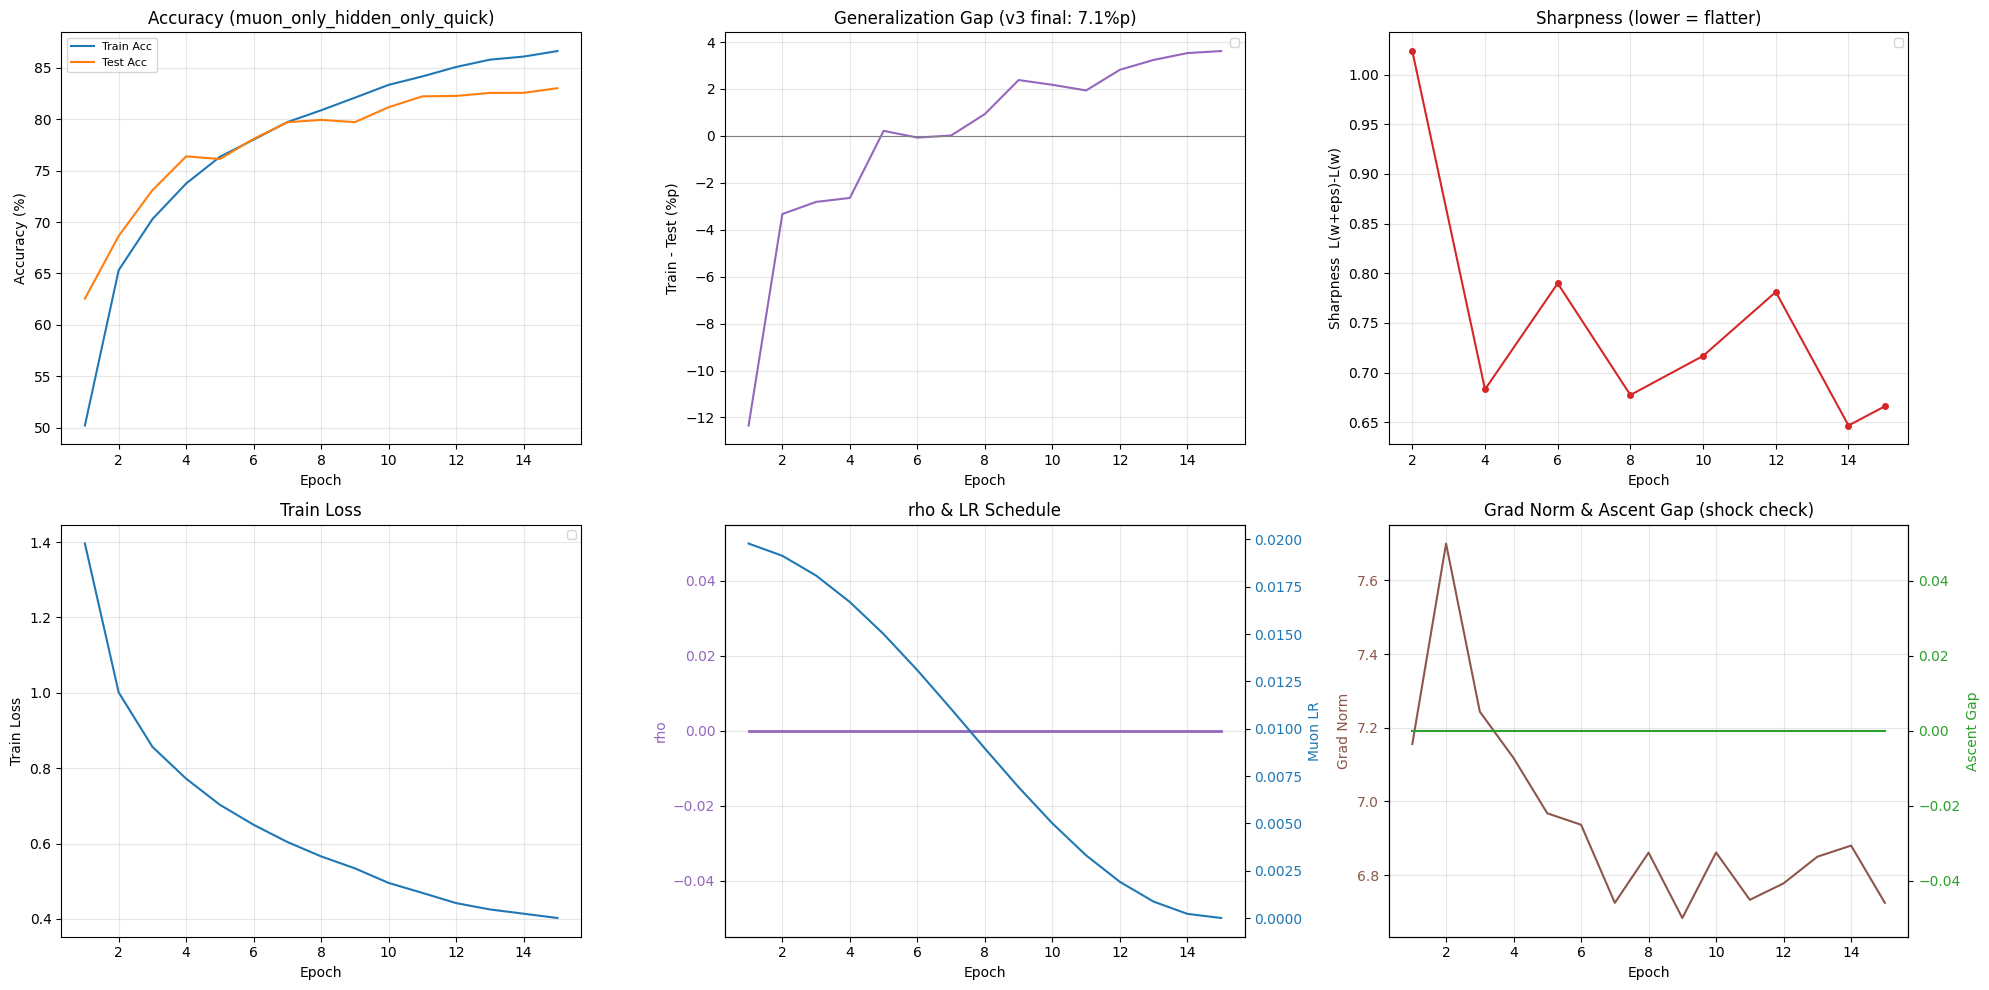


📊 muon_only_hidden_only_quick
   Train Acc : 86.65%  (v3 50ep: 93.29%)
   Test Acc  : 83.03%  (v3 50ep: 86.20%)
   Gap       : 3.62%p  (v3 50ep: 7.09%p)
   Sharpness : 0.6660


In [9]:
# ==========================================
# 8. 결과 시각화
# ==========================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
ramp_start = controller.trigger_epoch
ramp_end = (controller.trigger_epoch + controller.ramp_epochs) if ramp_start is not None else None

def shade_phases(ax):
    if ramp_start is not None:
        ax.axvspan(ramp_start, min(ramp_end, EPOCHS), color='orange', alpha=0.12, label='rho ramp')
        ax.axvline(ramp_start, color='orange', linestyle='--', linewidth=1)

# 1. Accuracy — train/test 갭이 핵심 진단 지표
ax = axes[0, 0]
ax.plot(history['epoch'], history['train_acc'], color='tab:blue', label='Train Acc', linewidth=1.5)
ax.plot(history['epoch'], history['test_acc'], color='tab:orange', label='Test Acc', linewidth=1.5)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.set_title(f'Accuracy ({RUN_TAG})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 2. Train-Test Gap — 과적합 vs 과소적합 판정
ax = axes[0, 1]
gap = [tr - te for tr, te in zip(history['train_acc'], history['test_acc'])]
ax.plot(history['epoch'], gap, color='tab:purple', linewidth=1.5)
ax.axhline(0, color='gray', linewidth=0.8)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Train - Test (%p)')
ax.set_title('Generalization Gap (v3 final: 7.1%p)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 3. Sharpness
ax = axes[0, 2]
ax.plot(sharpness_history['epoch'], sharpness_history['sharpness'],
        color='tab:red', marker='o', markersize=4, linewidth=1.5)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Sharpness  L(w+eps)-L(w)')
ax.set_title('Sharpness (lower = flatter)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 4. Train Loss
ax = axes[1, 0]
ax.plot(history['epoch'], history['train_loss'], color='tab:blue', linewidth=1.5)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss'); ax.set_title('Train Loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 5. rho + LR
ax = axes[1, 1]
ax.plot(history['epoch'], history['rho'], color='tab:purple', linewidth=2, label='rho')
ax.set_xlabel('Epoch'); ax.set_ylabel('rho', color='tab:purple')
ax.tick_params(axis='y', labelcolor='tab:purple')
ax2 = ax.twinx()
ax2.plot(history['epoch'], history['lr_muon'], color='tab:blue', linewidth=1.5, label='Muon LR')
ax2.set_ylabel('Muon LR', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax.set_title('rho & LR Schedule')
ax.grid(alpha=0.3)

# 6. Grad Norm + Ascent Gap
ax = axes[1, 2]
ax.plot(history['epoch'], history['grad_norm'], color='tab:brown', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Grad Norm', color='tab:brown')
ax.tick_params(axis='y', labelcolor='tab:brown')
shade_phases(ax)
ax2 = ax.twinx()
ax2.plot(history['epoch'], history['ascent_gap'], color='tab:green', linewidth=1.5)
ax2.set_ylabel('Ascent Gap', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax.set_title('Grad Norm & Ascent Gap (shock check)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'/content/v4_{RUN_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 {RUN_TAG}")
print(f"   Train Acc : {history['train_acc'][-1]:.2f}%  (v3 50ep: 93.29%)")
print(f"   Test Acc  : {history['test_acc'][-1]:.2f}%  (v3 50ep: 86.20%)")
print(f"   Gap       : {gap[-1]:.2f}%p  (v3 50ep: 7.09%p)")
print(f"   Sharpness : {final_sharpness:.4f}")

In [13]:
# ==========================================
# 7. 학습 루프 (v4)
# ==========================================
# ┌────────────────────────────────────────────────────────────────┐
# │ 1단계 진단: QUICK_TEST=True, MODE='muon_only',                  │
# │             MUON_SCOPE='hidden_only' 로 15에폭 (~15분)          │
# │   → v3의 muon_only 15에폭 train acc = 85.19%                    │
# │     이보다 확실히 높으면 가설 적중                              │
# │                                                                 │
# │ 2단계 본실험: QUICK_TEST=False 로 muon_only → hybrid            │
# └────────────────────────────────────────────────────────────────┘
MODE = 'muon_only'          # 'muon_only' | 'sam_always' | 'hybrid'
MUON_SCOPE = 'hidden_only'  # ★ 'hidden_only'(권장) | 'all'(v3 재현)
QUICK_TEST = False           # True면 15에폭만

EPOCHS = 15 if QUICK_TEST else 50
SCHEDULE_EPOCHS = 50      # ★ cosine T_max는 항상 50 고정.
                          #   QUICK_TEST는 50에폭 스케줄의 앞 15에폭만 잘라 보는 것이 되어야
                          #   v3의 같은 에폭 시점과 공정 비교가 된다.
MUON_LR = 0.02
MUON_WD = 0.0             # Muon weight decay (0.01~0.05 시도해볼 것)
ADAMW_LR = 3e-4
RHO_MAX = 0.05
RAMP_EPOCHS = 5
SHARPNESS_INTERVAL = 2
GRAD_CLIP = 1.0

torch.manual_seed(42)
model = build_model()

# ★ v4 핵심: scope 정책에 따라 파라미터 분리
muon_params, adamw_params = split_params(model, scope=MUON_SCOPE)

optimizer_muon = Muon(muon_params, lr=MUON_LR, momentum=0.95, weight_decay=MUON_WD)
optimizer_adamw = optim.AdamW(adamw_params, lr=ADAMW_LR, weight_decay=0.01)

sched_muon = optim.lr_scheduler.CosineAnnealingLR(optimizer_muon, T_max=SCHEDULE_EPOCHS)
sched_adamw = optim.lr_scheduler.CosineAnnealingLR(optimizer_adamw, T_max=SCHEDULE_EPOCHS)

sam = SAMAscent(model.parameters(), rho=0.0)

controller = RampSwitchController(
    rho_max=RHO_MAX, ramp_epochs=RAMP_EPOCHS,
    coarse_loss_threshold=0.5, coarse_window=3, coarse_std_threshold=0.03,
    mode=MODE,
)

criterion = nn.CrossEntropyLoss()

history = {'epoch': [], 'phase': [], 'rho': [], 'train_loss': [], 'train_acc': [],
           'test_acc': [], 'lr_muon': [], 'lr_adamw': [], 'grad_norm': [],
           'ascent_gap': [], 'time': []}
sharpness_history = {'epoch': [], 'sharpness': []}

RUN_TAG = f"{MODE}_{MUON_SCOPE}" + ("_quick" if QUICK_TEST else "")
print(f"🚀 CIFAR-10 학습 시작 — {RUN_TAG}, {EPOCHS} epochs\n")

for epoch in range(EPOCHS):
    rho_now = controller.current_rho(epoch)
    sam.set_rho(rho_now)
    phase = controller.phase

    model.train()
    running_loss, running_gap, running_gnorm = 0.0, 0.0, 0.0
    correct, total = 0, 0
    n_batches = 0
    start_time = time.time()

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer_muon.zero_grad(set_to_none=True)
        optimizer_adamw.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()

        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        with torch.no_grad():
            gnorm = torch.norm(torch.stack([
                p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]), p=2).item()
        running_gnorm += gnorm

        gap = 0.0
        if sam.ascent():
            optimizer_muon.zero_grad(set_to_none=True)
            optimizer_adamw.zero_grad(set_to_none=True)
            loss_adv = criterion(model(inputs), targets)
            loss_adv.backward()
            gap = loss_adv.item() - loss.item()
            sam.restore()

        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer_muon.step()
        optimizer_adamw.step()

        running_loss += loss.item()
        running_gap += gap
        n_batches += 1

    sched_muon.step()
    sched_adamw.step()

    epoch_time = time.time() - start_time
    train_loss = running_loss / n_batches
    train_acc = 100. * correct / total
    test_acc = evaluate(model, test_loader)

    history['epoch'].append(epoch + 1)
    history['phase'].append(phase)
    history['rho'].append(rho_now)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    history['lr_muon'].append(optimizer_muon.param_groups[0]['lr'])
    history['lr_adamw'].append(optimizer_adamw.param_groups[0]['lr'])
    history['grad_norm'].append(running_gnorm / n_batches)
    history['ascent_gap'].append(running_gap / n_batches)
    history['time'].append(epoch_time)

    sharp_str = ""
    if (epoch + 1) % SHARPNESS_INTERVAL == 0 or epoch == EPOCHS - 1:
        sv = measure_sharpness(model, criterion, probe_batches, device, rho=0.05)
        sharpness_history['epoch'].append(epoch + 1)
        sharpness_history['sharpness'].append(sv)
        sharp_str = f" | Sharp: {sv:.4f}"

    phase_tag = {1: "P1-Muon", 2: "P2-Ramp", 3: "P3-SAMMuon"}[phase]
    print(f"[{phase_tag}] Ep [{epoch+1}/{EPOCHS}] | {epoch_time:.1f}s | "
          f"Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}% | "
          f"rho: {rho_now:.4f}{sharp_str}")

    controller.update(epoch, train_loss)

best_acc = max(history['test_acc'])
best_epoch = history['epoch'][history['test_acc'].index(best_acc)]
final_sharpness = sharpness_history['sharpness'][-1]

print(f"\n🎉 학습 종료! ({RUN_TAG})")
print(f"   - 최종 Train Acc: {history['train_acc'][-1]:.2f}%")
print(f"   - 최종 Test Acc : {history['test_acc'][-1]:.2f}%")
print(f"   - 최고 Test Acc : {best_acc:.2f}% (epoch {best_epoch})")
print(f"   - 최종 Sharpness: {final_sharpness:.4f}")
print(f"   - 총 학습 시간  : {sum(history['time'])/60:.1f}분")

# ---- v3 대비 진단 ----
# v3 muon_only(scope='all') 실측값. ※ 15ep test는 이전 버전에서 hybrid 값(82.11)을
# 잘못 넣었던 것을 정정 (올바른 muon_only 값은 83.55)
V3_REF = {15: {'train': 85.19, 'test': 83.55}, 50: {'train': 93.29, 'test': 86.20}}
if EPOCHS in V3_REF and MODE == 'muon_only':
    ref = V3_REF[EPOCHS]
    d_train = history['train_acc'][-1] - ref['train']
    d_test = history['test_acc'][-1] - ref['test']
    print(f"\n📌 v3 muon_only({EPOCHS}ep) 대비: "
          f"Train {ref['train']:.2f}% → {history['train_acc'][-1]:.2f}% ({d_train:+.2f}%p) | "
          f"Test {ref['test']:.2f}% → {history['test_acc'][-1]:.2f}% ({d_test:+.2f}%p)")
    gap_now = history['train_acc'][-1] - history['test_acc'][-1]
    gap_ref = ref['train'] - ref['test']
    print(f"   Gap: {gap_ref:.2f}%p → {gap_now:.2f}%p ({gap_now-gap_ref:+.2f}%p)")
    if d_train > 1.0 and d_test > 0.3:
        print("   ✅ 가설 적중 — fitting/일반화 동시 개선. 본 실험 진행!")
    elif d_train > 1.0:
        print("   ⚖️  fitting은 개선(train↑), 일반화는 아직(test↔/↓). gap이 벌어졌다면")
        print("      '과적합 여지가 생긴 것'이므로 SAM이 일할 공간이 마련된 상태.")
        print("      → hybrid/sam_always를 돌려서 SAM이 이 gap을 줄이는지 확인할 차례")
    elif d_train > 0.3:
        print("   🤔 소폭 개선 — MUON_WD/MUON_LR도 함께 조정 권장")
    else:
        print("   ❌ 개선 없음 — scope는 원인이 아님. 아래 마크다운의 '가설이 틀렸을 때' 참고")


⚙️  MUON_SCOPE='hidden_only'
    Muon :  19개 텐서 /  11,157,504 params
    AdamW:  43개 텐서 /      24,138 params
    Muon에서 제외된 레이어:
      - conv1.weight         (64, 3, 7, 7)         9,408
      - fc.weight            (10, 512)             5,120

🚀 CIFAR-10 학습 시작 — muon_only_hidden_only, 50 epochs

[P1-Muon] Ep [1/50] | 48.8s | Loss: 1.3835 | Train: 50.78% | Test: 62.54% | rho: 0.0000
[P1-Muon] Ep [2/50] | 50.8s | Loss: 0.9942 | Train: 65.65% | Test: 69.37% | rho: 0.0000 | Sharp: 0.9095
[P1-Muon] Ep [3/50] | 50.9s | Loss: 0.8570 | Train: 70.59% | Test: 73.02% | rho: 0.0000
[P1-Muon] Ep [4/50] | 51.5s | Loss: 0.7760 | Train: 73.61% | Test: 75.15% | rho: 0.0000 | Sharp: 0.6499
[P1-Muon] Ep [5/50] | 51.5s | Loss: 0.7237 | Train: 75.31% | Test: 76.19% | rho: 0.0000
[P1-Muon] Ep [6/50] | 51.2s | Loss: 0.6755 | Train: 77.11% | Test: 77.68% | rho: 0.0000 | Sharp: 0.5351
[P1-Muon] Ep [7/50] | 51.2s | Loss: 0.6324 | Train: 78.76% | Test: 78.80% | rho: 0.0000
[P1-Muon] Ep [8/50] | 51.3s | Loss: 0.6

/tmp/ipykernel_1331/997928366.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8); ax.grid(alpha=0.3)
/tmp/ipykernel_1331/997928366.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8); ax.grid(alpha=0.3)
/tmp/ipykernel_1331/997928366.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8); ax.grid(alpha=0.3)


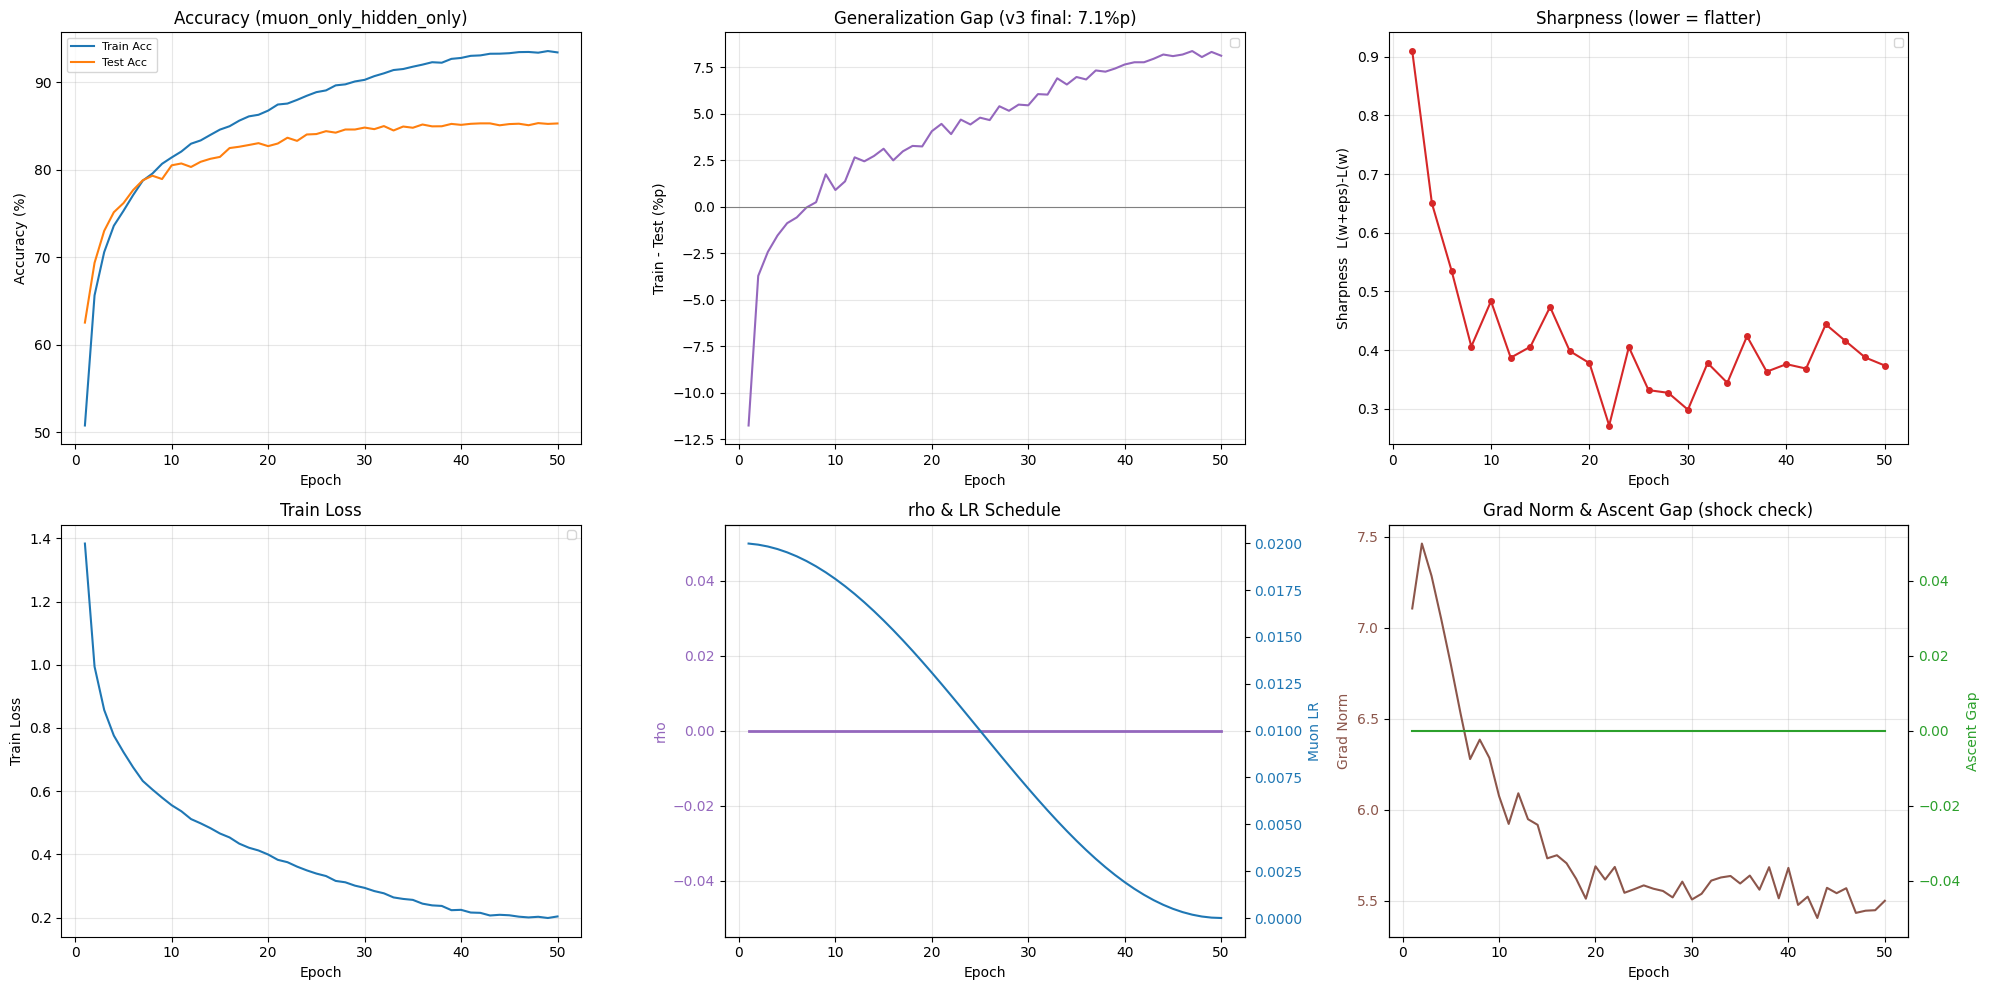


📊 muon_only_hidden_only
   Train Acc : 93.41%  (v3 50ep: 93.29%)
   Test Acc  : 85.29%  (v3 50ep: 86.20%)
   Gap       : 8.12%p  (v3 50ep: 7.09%p)
   Sharpness : 0.3738


In [14]:
# ==========================================
# 8. 결과 시각화
# ==========================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
ramp_start = controller.trigger_epoch
ramp_end = (controller.trigger_epoch + controller.ramp_epochs) if ramp_start is not None else None

def shade_phases(ax):
    if ramp_start is not None:
        ax.axvspan(ramp_start, min(ramp_end, EPOCHS), color='orange', alpha=0.12, label='rho ramp')
        ax.axvline(ramp_start, color='orange', linestyle='--', linewidth=1)

# 1. Accuracy — train/test 갭이 핵심 진단 지표
ax = axes[0, 0]
ax.plot(history['epoch'], history['train_acc'], color='tab:blue', label='Train Acc', linewidth=1.5)
ax.plot(history['epoch'], history['test_acc'], color='tab:orange', label='Test Acc', linewidth=1.5)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.set_title(f'Accuracy ({RUN_TAG})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 2. Train-Test Gap — 과적합 vs 과소적합 판정
ax = axes[0, 1]
gap = [tr - te for tr, te in zip(history['train_acc'], history['test_acc'])]
ax.plot(history['epoch'], gap, color='tab:purple', linewidth=1.5)
ax.axhline(0, color='gray', linewidth=0.8)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Train - Test (%p)')
ax.set_title('Generalization Gap (v3 final: 7.1%p)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 3. Sharpness
ax = axes[0, 2]
ax.plot(sharpness_history['epoch'], sharpness_history['sharpness'],
        color='tab:red', marker='o', markersize=4, linewidth=1.5)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Sharpness  L(w+eps)-L(w)')
ax.set_title('Sharpness (lower = flatter)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 4. Train Loss
ax = axes[1, 0]
ax.plot(history['epoch'], history['train_loss'], color='tab:blue', linewidth=1.5)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss'); ax.set_title('Train Loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 5. rho + LR
ax = axes[1, 1]
ax.plot(history['epoch'], history['rho'], color='tab:purple', linewidth=2, label='rho')
ax.set_xlabel('Epoch'); ax.set_ylabel('rho', color='tab:purple')
ax.tick_params(axis='y', labelcolor='tab:purple')
ax2 = ax.twinx()
ax2.plot(history['epoch'], history['lr_muon'], color='tab:blue', linewidth=1.5, label='Muon LR')
ax2.set_ylabel('Muon LR', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax.set_title('rho & LR Schedule')
ax.grid(alpha=0.3)

# 6. Grad Norm + Ascent Gap
ax = axes[1, 2]
ax.plot(history['epoch'], history['grad_norm'], color='tab:brown', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Grad Norm', color='tab:brown')
ax.tick_params(axis='y', labelcolor='tab:brown')
shade_phases(ax)
ax2 = ax.twinx()
ax2.plot(history['epoch'], history['ascent_gap'], color='tab:green', linewidth=1.5)
ax2.set_ylabel('Ascent Gap', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax.set_title('Grad Norm & Ascent Gap (shock check)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'/content/v4_{RUN_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 {RUN_TAG}")
print(f"   Train Acc : {history['train_acc'][-1]:.2f}%  (v3 50ep: 93.29%)")
print(f"   Test Acc  : {history['test_acc'][-1]:.2f}%  (v3 50ep: 86.20%)")
print(f"   Gap       : {gap[-1]:.2f}%p  (v3 50ep: 7.09%p)")
print(f"   Sharpness : {final_sharpness:.4f}")


In [15]:
# ==========================================
# 9. 결과 저장 (MyDrive)
# ==========================================
import json
from datetime import datetime

save_dir = '/content/drive/MyDrive/Colab_Data/hybrid_experiments'
os.makedirs(save_dir, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_name = f'v4_{RUN_TAG}_{timestamp}'

run_record = {
    'run_name': run_name,
    'version': 'v4',
    'mode': MODE,
    'muon_scope': MUON_SCOPE,
    'quick_test': QUICK_TEST,
    'config': {
        'epochs': EPOCHS, 'schedule_epochs': SCHEDULE_EPOCHS,
        'muon_lr': MUON_LR, 'muon_wd': MUON_WD,
        'adamw_lr': ADAMW_LR, 'rho_max': RHO_MAX, 'ramp_epochs': RAMP_EPOCHS,
        'grad_clip': GRAD_CLIP, 'lr_schedule': 'CosineAnnealingLR',
    },
    'results': {
        'final_train_acc': history['train_acc'][-1],
        'final_test_acc': history['test_acc'][-1],
        'best_test_acc': best_acc,
        'best_epoch': best_epoch,
        'final_train_loss': history['train_loss'][-1],
        'final_gap': history['train_acc'][-1] - history['test_acc'][-1],
        'final_sharpness': final_sharpness,
        'total_time_min': sum(history['time']) / 60,
        'ramp_start_epoch': controller.trigger_epoch,
    },
    'history': history,
    'sharpness_history': sharpness_history,
}

with open(os.path.join(save_dir, f'{run_name}.json'), 'w', encoding='utf-8') as f:
    json.dump(run_record, f, ensure_ascii=False, indent=2)

torch.save(model.state_dict(), os.path.join(save_dir, f'{run_name}_model.pt'))
print(f"✅ 저장 완료: {save_dir}/{run_name}.json")

✅ 저장 완료: /content/drive/MyDrive/Colab_Data/hybrid_experiments/v4_muon_only_hidden_only_20260820_021147.json


📂 불러온 실험 4개



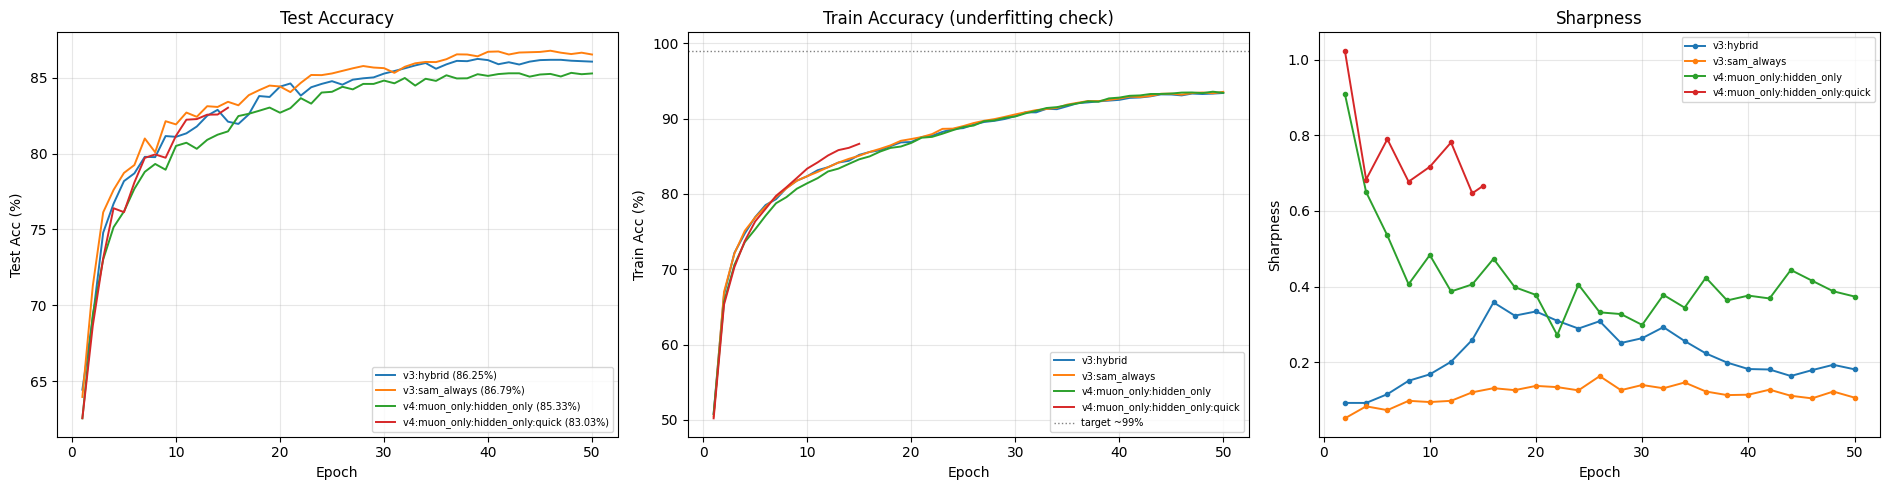

실험                                  Train     Test      Gap     Sharp       분
------------------------------------------------------------------------------
v3:hybrid                          93.39%   86.07%     nanp    0.1812    52.4
v3:sam_always                      93.54%   86.54%     nanp    0.1064    58.2
v4:muon_only:hidden_only           93.41%   85.29%    8.12p    0.3738    42.7
v4:muon_only:hidden_only:quick     86.65%   83.03%    3.62p    0.6660    12.8
------------------------------------------------------------------------------
[참고] SAM 단독 (v1 로그)                     —   94.69%


In [16]:
# ==========================================
# 10. v3 + v4 전체 결과 통합 비교
# ==========================================
import glob
import matplotlib.pyplot as plt

save_dir = '/content/drive/MyDrive/Colab_Data/hybrid_experiments'
runs = {}
for fp in sorted(glob.glob(os.path.join(save_dir, 'v*.json'))):
    with open(fp, encoding='utf-8') as f:
        rec = json.load(f)
    ver = rec.get('version', 'v3')
    scope = rec.get('muon_scope', 'all')
    key = f"{ver}:{rec['mode']}" + (f":{scope}" if ver == 'v4' else "")
    if rec.get('quick_test'):
        key += ":quick"
    runs[key] = rec

if not runs:
    print("⚠️ 저장된 결과가 없습니다.")
else:
    print(f"📂 불러온 실험 {len(runs)}개\n")

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    cmap = plt.get_cmap('tab10')
    colors = {k: cmap(i % 10) for i, k in enumerate(runs)}

    ax = axes[0]
    for k, rec in runs.items():
        ax.plot(rec['history']['epoch'], rec['history']['test_acc'],
                label=f"{k} ({rec['results']['best_test_acc']:.2f}%)",
                color=colors[k], linewidth=1.4)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc (%)'); ax.set_title('Test Accuracy')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = axes[1]
    for k, rec in runs.items():
        ax.plot(rec['history']['epoch'], rec['history']['train_acc'],
                label=k, color=colors[k], linewidth=1.4)
    ax.axhline(99, color='gray', linestyle=':', linewidth=1, label='target ~99%')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Train Acc (%)')
    ax.set_title('Train Accuracy (underfitting check)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = axes[2]
    for k, rec in runs.items():
        ax.plot(rec['sharpness_history']['epoch'], rec['sharpness_history']['sharpness'],
                label=k, color=colors[k], marker='o', markersize=3, linewidth=1.4)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Sharpness'); ax.set_title('Sharpness')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/v4_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"{'실험':<32} {'Train':>8} {'Test':>8} {'Gap':>8} {'Sharp':>9} {'분':>7}")
    print("-" * 78)
    for k, rec in runs.items():
        r = rec['results']
        tr = r.get('final_train_acc', float('nan'))
        gp = r.get('final_gap', float('nan'))
        print(f"{k:<32} {tr:>7.2f}% {r['final_test_acc']:>7.2f}% "
              f"{gp:>7.2f}p {r['final_sharpness']:>9.4f} {r['total_time_min']:>7.1f}")
    print("-" * 78)
    print(f"{'[참고] SAM 단독 (v1 로그)':<32} {'—':>8} {'94.69%':>8}")